<a href="https://colab.research.google.com/github/mdNotFound/100-days-of-ai-engineering/blob/main/Cardiac_Disease_Prediction_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **IMPORTS**

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay

In [38]:
df=pd.read_csv("/content/heart_disease_uci.csv")

# **EDA AND PREPROCESSING**

In [39]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


## dataset contains 920 patient records with both numerical and categorical features

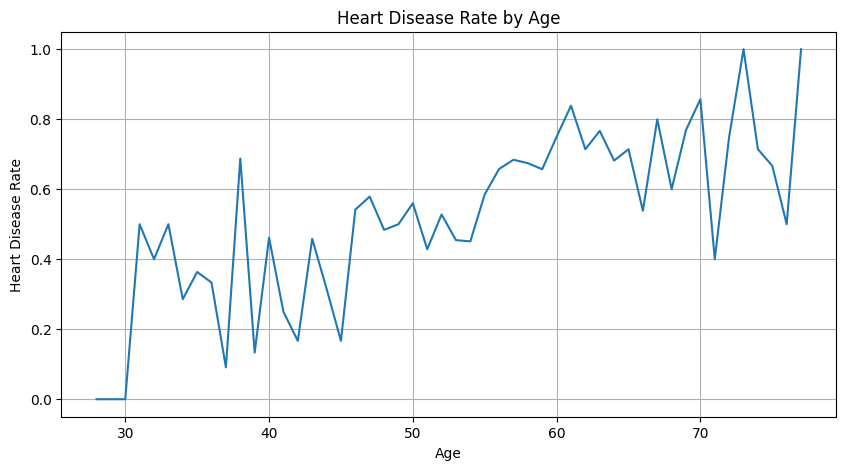

In [62]:
df.groupby('age')['target'].mean().plot(
    figsize=(10, 5)
)
plt.title('Heart Disease Rate by Age')
plt.xlabel('Age')
plt.ylabel('Heart Disease Rate')
plt.grid()
plt.show()

## heart disease rate generally tends to increase with age

In [41]:
df['num'].value_counts().sort_index()

,count
num,
0,411
1,265
2,109
3,107
4,28


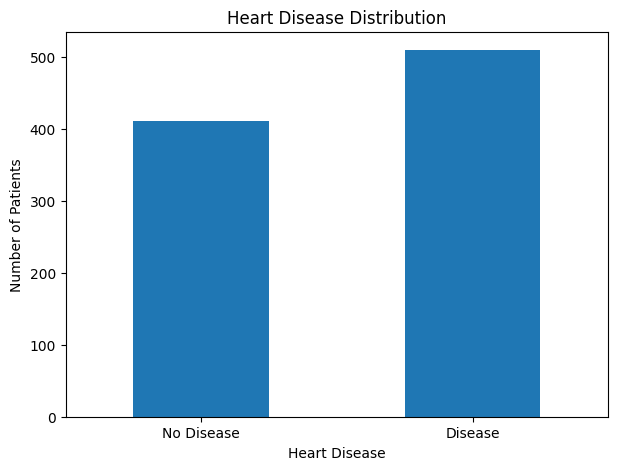

In [61]:
df['target'].value_counts().sort_index().plot(
    kind='bar',
    figsize=(7, 5)
)
plt.title('Heart Disease Distribution')
plt.xlabel('Heart Disease')
plt.ylabel('Number of Patients')
plt.xticks([0, 1], ['No Disease', 'Disease'], rotation=0)
plt.show()

## The dataset contains 509 patients with heart disease and 411 patients without heart disease

## creating binary targets

In [42]:
df['target'] = (df['num'] > 0).astype(int)
df['target'].value_counts()

,count
target,
1,509
0,411


##  converted the targets into a binary classification problem:
 ## 0 = No heart disease
##  1 = Heart disease

## seperating targets and features

In [43]:
X = df.drop(columns=['num', 'target', 'id'])
y = df['target']

## spliting data into train and test

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [45]:
print("training:", X_train.shape)
print("testing :", X_test.shape)

training: (736, 14)
testing : (184, 14)


## imputing and scaling

In [46]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'bool']).columns

In [47]:
print("Numeric:", list(numeric_features))
print("Categorical:", list(categorical_features))

Numeric: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
Categorical: ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


In [48]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

## handled num missing values using median and cat values were handle using most frequent values

# **Model Training**

## Logistic regression

In [49]:
logistic_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

In [50]:
logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal'], dtype='object'))])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [51]:
y_pred = logistic_model.predict(X_test)

In [52]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))

Accuracy : 0.8369565217391305
Precision: 0.8272727272727273
Recall   : 0.8921568627450981
F1-score : 0.8584905660377359


In [53]:
print(confusion_matrix(y_test, y_pred))

[[63 19]
 [11 91]]


## random forest classifier

In [54]:
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

In [55]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal'], dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [56]:
rf_pred = rf_model.predict(X_test)

In [57]:
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1-score :", f1_score(y_test, rf_pred))

Accuracy : 0.8478260869565217
Precision: 0.8557692307692307
Recall   : 0.8725490196078431
F1-score : 0.8640776699029126


In [58]:
print(confusion_matrix(y_test, rf_pred))

[[67 15]
 [13 89]]


## Model comaparison

In [59]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred)
    ],
    'Precision': [
        precision_score(y_test, y_pred),
        precision_score(y_test, rf_pred)
    ],
    'Recall': [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_pred)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.836957,0.827273,0.892157,0.858491
1,Random Forest,0.847826,0.855769,0.872549,0.864078


## random forest was slightly better than logistic regression maybe bcz its a tree based model

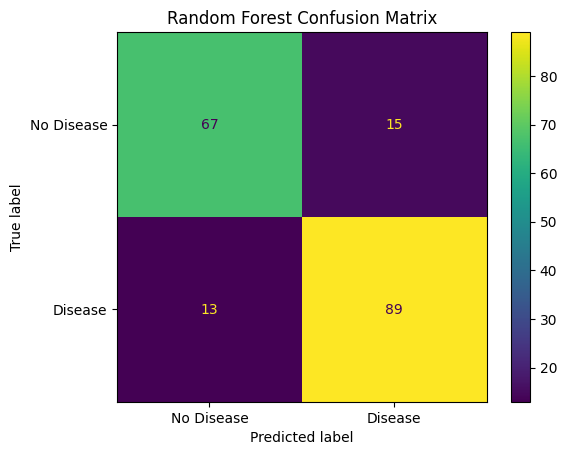

In [60]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    display_labels=['No Disease', 'Disease']
)

plt.title('Random Forest Confusion Matrix')
plt.show()

## Random Forest correctly classified 67 patients without heart disease and 89 patients with heart disease